In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import pickle

import matplotlib as mpl
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [2]:
# Assume precision recall and f1 summary stat files are already calculated
main_indir = "/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/precision_recall_variable_rates"
all_f1_files = glob.glob(f"{main_indir}/*/*metrics.csv")
all_precision_recall_files = glob.glob(f"{main_indir}/*/*precision_recall_vars.pkl")

print("F1 files:", all_f1_files)
print(len(all_f1_files))
print("Precision recall files:", all_precision_recall_files)
print(len(all_precision_recall_files))

F1 files: ['/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/precision_recall_variable_rates/mig7_mut005/metrics.csv', '/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/precision_recall_variable_rates/mig4_mut0005/metrics.csv', '/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/precision_recall_variable_rates/mig4_mut0025/metrics.csv', '/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/precision_recall_variable_rates/mig5_mut0005/metrics.csv', '/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/precision_recall_variable_rates/mig4_mut001/metrics.csv', '/grid/siepel/home/staklins/projects/cris

In [3]:
f1_dfs = {}
for f1_file in all_f1_files:
    var_rates_category = os.path.basename(os.path.dirname(f1_file))
    df = pd.read_csv(f1_file, index_col=0)
    cols_to_keep = [col for col in df.columns if "f1" in col]
    df = df[cols_to_keep]
    df.columns = [col.replace("_f1", "") for col in df.columns]
    f1_dfs[var_rates_category] = df
    
precision_recall_data = {}
for pr_file in all_precision_recall_files:
    var_rates_category = os.path.basename(os.path.dirname(pr_file))
    with open(pr_file, "rb") as file:
        pathfinder_precisions, pathfinder_recalls, machina_precisions, machina_recalls, random_precisions, random_recalls, consensus_precisions, consensus_recalls, parsimony_precisions, parsimony_recalls, metient_all_thresh_df, mach2_all_thresh_df, all_thresh_df = pickle.load(file)
    data_dict = {
        "pathfinder_precision": pathfinder_precisions,
        "pathfinder_recall": pathfinder_recalls,
        "machina_precision": machina_precisions,
        "machina_recall": machina_recalls,
        "random_precision": random_precisions,
        "random_recall": random_recalls,
        "consensus_precision": consensus_precisions,
        "consensus_recall": consensus_recalls,
        "parsimony_precision": parsimony_precisions,
        "parsimony_recall": parsimony_recalls,
        "metient_all_thresh_df": metient_all_thresh_df,
        "mach2_all_thresh_df": mach2_all_thresh_df,
        "all_thresh_df": all_thresh_df
    }
    precision_recall_data[var_rates_category] = data_dict
    
print(len(f1_dfs))
print(len(precision_recall_data))

20
20


In [4]:
def parse_var_category(var_rates_category):
    """
    Converts strings like 'mig5_mut0025' → migration=1e-5, mutation=0.0025
    """
    mig_rate = 10**-float(var_rates_category.split("_")[0].replace("mig", ""))
    mut_rate = float("0." + str(var_rates_category.split("_")[1].replace("mut", "")))
    return mig_rate, mut_rate

def reverse_mig_mut_rate_to_category_key(mig_rate, mut_rate):
    """
    Converts migration and mutation rates like (0.0025, 1e-5) → 'mig5_mut0025'
    """
    # Extract the exponent of the migration rate (assuming form 1e-x)
    mig_exp = int(-np.log10(mig_rate))
    
    # Convert mutation rate (e.g., 0.0025 -> '00025' then trim to match your format)
    mut_str = f"{mut_rate:.4f}".replace("0.", "")
    mut_str = mut_str.rstrip("0")  # Remove trailing zeros for consistency
    
    # Construct the key
    return f"mig{mig_exp}_mut{mut_str}"

In [5]:
merged_f1_df = pd.DataFrame()
for var_rates_category, df in f1_dfs.items():
    df = df.copy()
    df["migration_rate"] , df["mutation_rate"] = parse_var_category(var_rates_category) 
    merged_f1_df = pd.concat([merged_f1_df, df], ignore_index=True)

In [6]:
print(merged_f1_df['mutation_rate'].unique())
print(merged_f1_df['migration_rate'].unique())

[0.005  0.0005 0.0025 0.001  0.01  ]
[1.e-07 1.e-04 1.e-05 1.e-06]


In [7]:
melted_f1_df = merged_f1_df.melt(
    id_vars=["migration_rate", "mutation_rate"],
    value_vars=[col for col in merged_f1_df.columns if not col.startswith("Metient_bestSol") and not "rate" in col],
    var_name="Method",
    value_name="F1"
)

print(melted_f1_df['Method'].unique())
print(melted_f1_df['mutation_rate'].unique())
print(melted_f1_df['migration_rate'].unique())

['Random' 'Consensus' 'Fitch-Hartigan' 'PathFinder' 'MACHINA' 'MACH2'
 'Metient' 'BEAM']
[0.005  0.0005 0.0025 0.001  0.01  ]
[1.e-07 1.e-04 1.e-05 1.e-06]


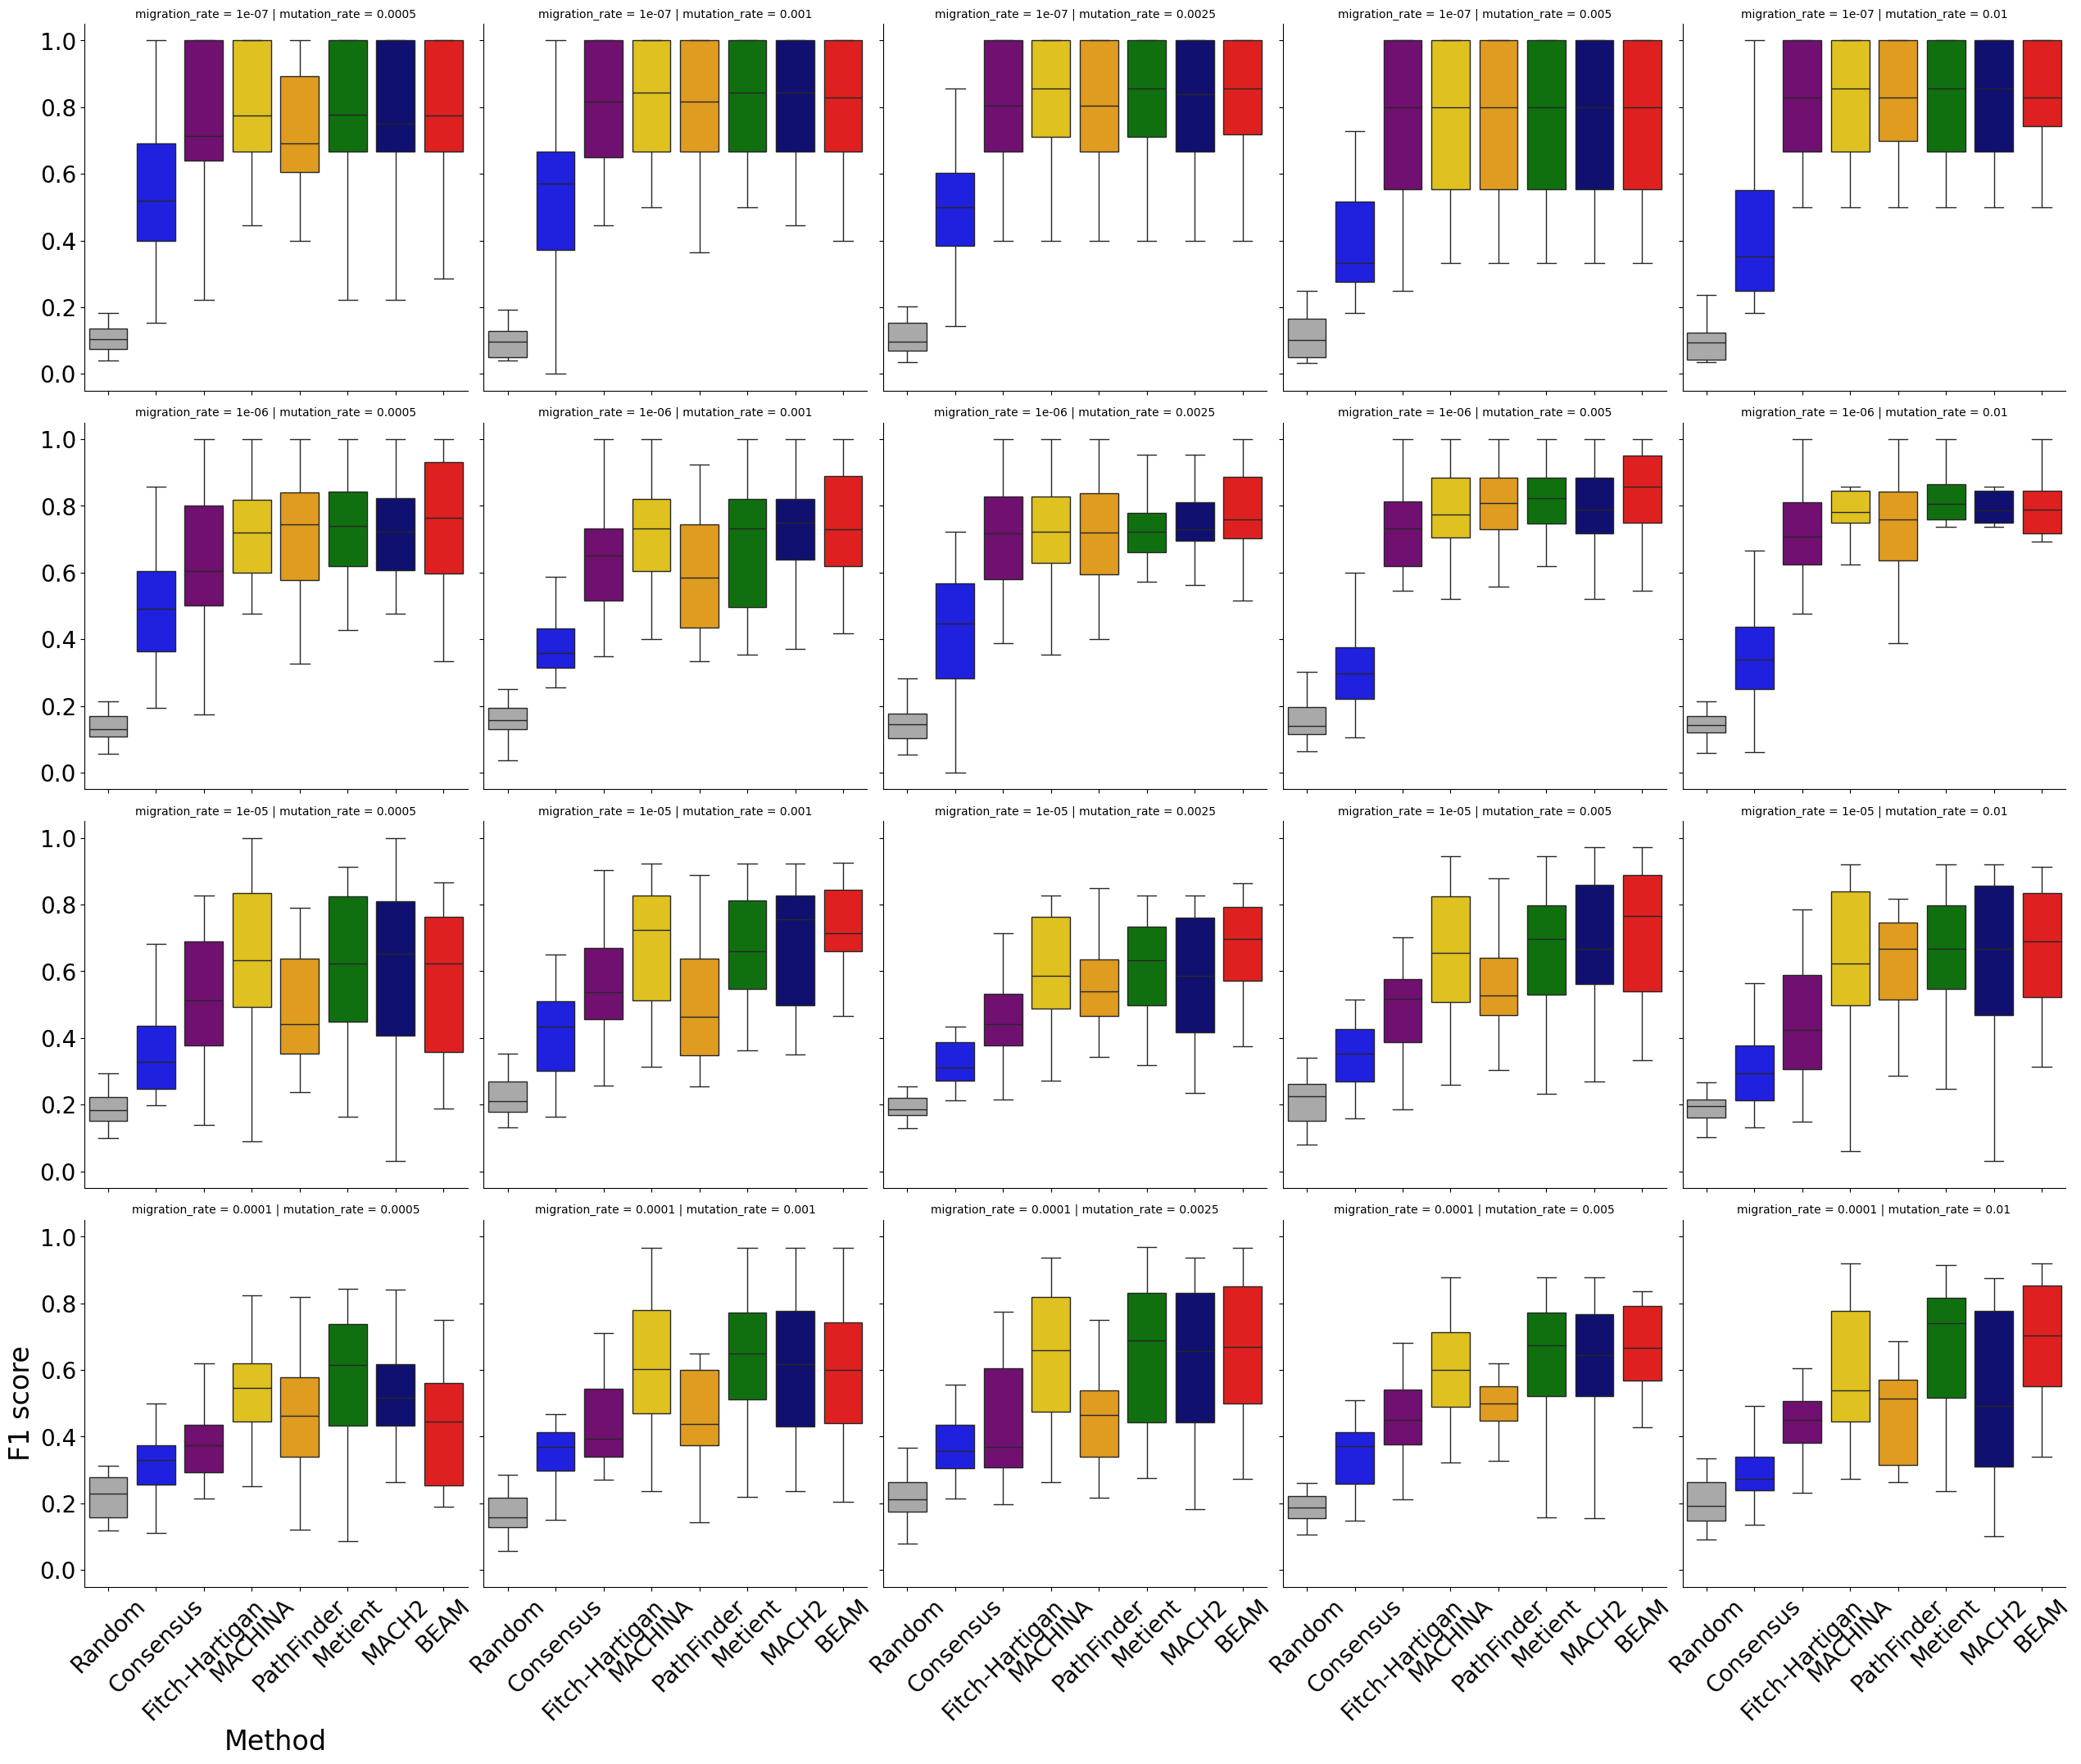

In [8]:
# Set desired method order
method_order = ["Random", "Consensus", "Fitch-Hartigan", "MACHINA", "PathFinder", "Metient", "MACH2", "BEAM"]

# Define consistent colors
palette = {
    "BEAM": "red",
    "Random": "darkgrey",
    "Fitch-Hartigan": "purple",
    "PathFinder": "orange",
    "MACHINA": "gold",
    "Metient": "green",
    "Consensus": "blue",
    "MACH2": "navy",
}

fs = 24

# Create a catplot with one facet per variable rate category
g = sns.catplot(
    data=melted_f1_df,
    x="Method",
    y="F1",
    hue="Method",
    row = "migration_rate",
    col="mutation_rate",
    kind="box",
    order=method_order,
    palette=palette,
    showfliers=False,
    sharey=True,
    sharex=True
)

# Get total rows and columns in the FacetGrid
n_rows, n_cols = g.axes.shape

# Select the bottom-left subplot
ax_bottom_left = g.axes[-1, 0]

# Set only its axis labels
ax_bottom_left.set_xlabel("Method", fontsize=fs)
ax_bottom_left.set_ylabel("F1 score", fontsize=fs)

# Optionally remove labels for all others (for a cleaner grid)
for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if not (i == n_rows - 1 and j == 0):
            ax.set_xlabel("")
            ax.set_ylabel("")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelsize=fs - 4, rotation=45)
    ax.tick_params(axis="y", labelsize=fs - 4)




In [9]:
def plot_one_pr_panel(ax, pathfinder_precisions, pathfinder_recalls, machina_precisions, machina_recalls, random_precisions, random_recalls, consensus_precisions, consensus_recalls, parsimony_precisions, parsimony_recalls, metient_all_thresh_df, mach2_all_thresh_df, all_thresh_df):

    size = 500
    textsize = 32

    avg_vals = lambda arr: np.nanmean(arr) if np.any(arr) else np.nan
    avg_pathfinder_precision, avg_pathfinder_recall = avg_vals(pathfinder_precisions), avg_vals(pathfinder_recalls)
    avg_machina_precision, avg_machina_recall = avg_vals(machina_precisions), avg_vals(machina_recalls)
    avg_random_precision, avg_random_recall = avg_vals(random_precisions), avg_vals(random_recalls)
    avg_consensus_precision, avg_consensus_recall = avg_vals(consensus_precisions), avg_vals(consensus_recalls)
    avg_parsimony_precision, avg_parsimony_recall = avg_vals(parsimony_precisions), avg_vals(parsimony_recalls)

    # Aggregate PR curves
    avg_df = all_thresh_df.groupby("Threshold")[["precision","recall"]].mean().reset_index() if not all_thresh_df.empty else None
    avg_mach2_df = mach2_all_thresh_df.groupby("Threshold")[["precision","recall"]].mean().reset_index() if not mach2_all_thresh_df.empty else None
    avg_metient_df = metient_all_thresh_df.groupby("Threshold")[["precision","recall"]].mean().reset_index() if not metient_all_thresh_df.empty else None

    # Plot curves and points
    if avg_df is not None:
        ax.plot(avg_df["recall"], avg_df["precision"], color="red", label="BEAM")
        for th, marker in [(0.50, "o"), (0.90, "s")]:
            sel = avg_df[avg_df["Threshold"] == th]
            if not sel.empty:
                ax.scatter(sel["recall"], sel["precision"], facecolors='red', edgecolors='red',
                           s=size/3, marker=marker, label=f"BEAM {th:.2f}")

    if avg_mach2_df is not None:
        ax.plot(avg_mach2_df["recall"], avg_mach2_df["precision"], color="navy", label="MACH2")
    if avg_metient_df is not None:
        ax.plot(avg_metient_df["recall"], avg_metient_df["precision"], color="green", label="Metient")

    scatter_points = [
        (avg_pathfinder_recall, avg_pathfinder_precision, "orange", "PathFinder"),
        (avg_machina_recall, avg_machina_precision, "gold", "MACHINA"),
        (avg_parsimony_recall, avg_parsimony_precision, "purple", "Fitch-Hartigan"),
        (avg_consensus_recall, avg_consensus_precision, "blue", "Consensus"),
        (avg_random_recall, avg_random_precision, "black", "Random"),
    ]
    for x, y, c, label in scatter_points:
        if not np.isnan(x) and not np.isnan(y):
            ax.scatter(x, y, color=c, label=label, s=size, marker="x")

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.set_xlabel("Recall", fontsize=textsize)
    ax.set_ylabel("Precision", fontsize=textsize)
    ax.tick_params(labelsize=textsize-4)

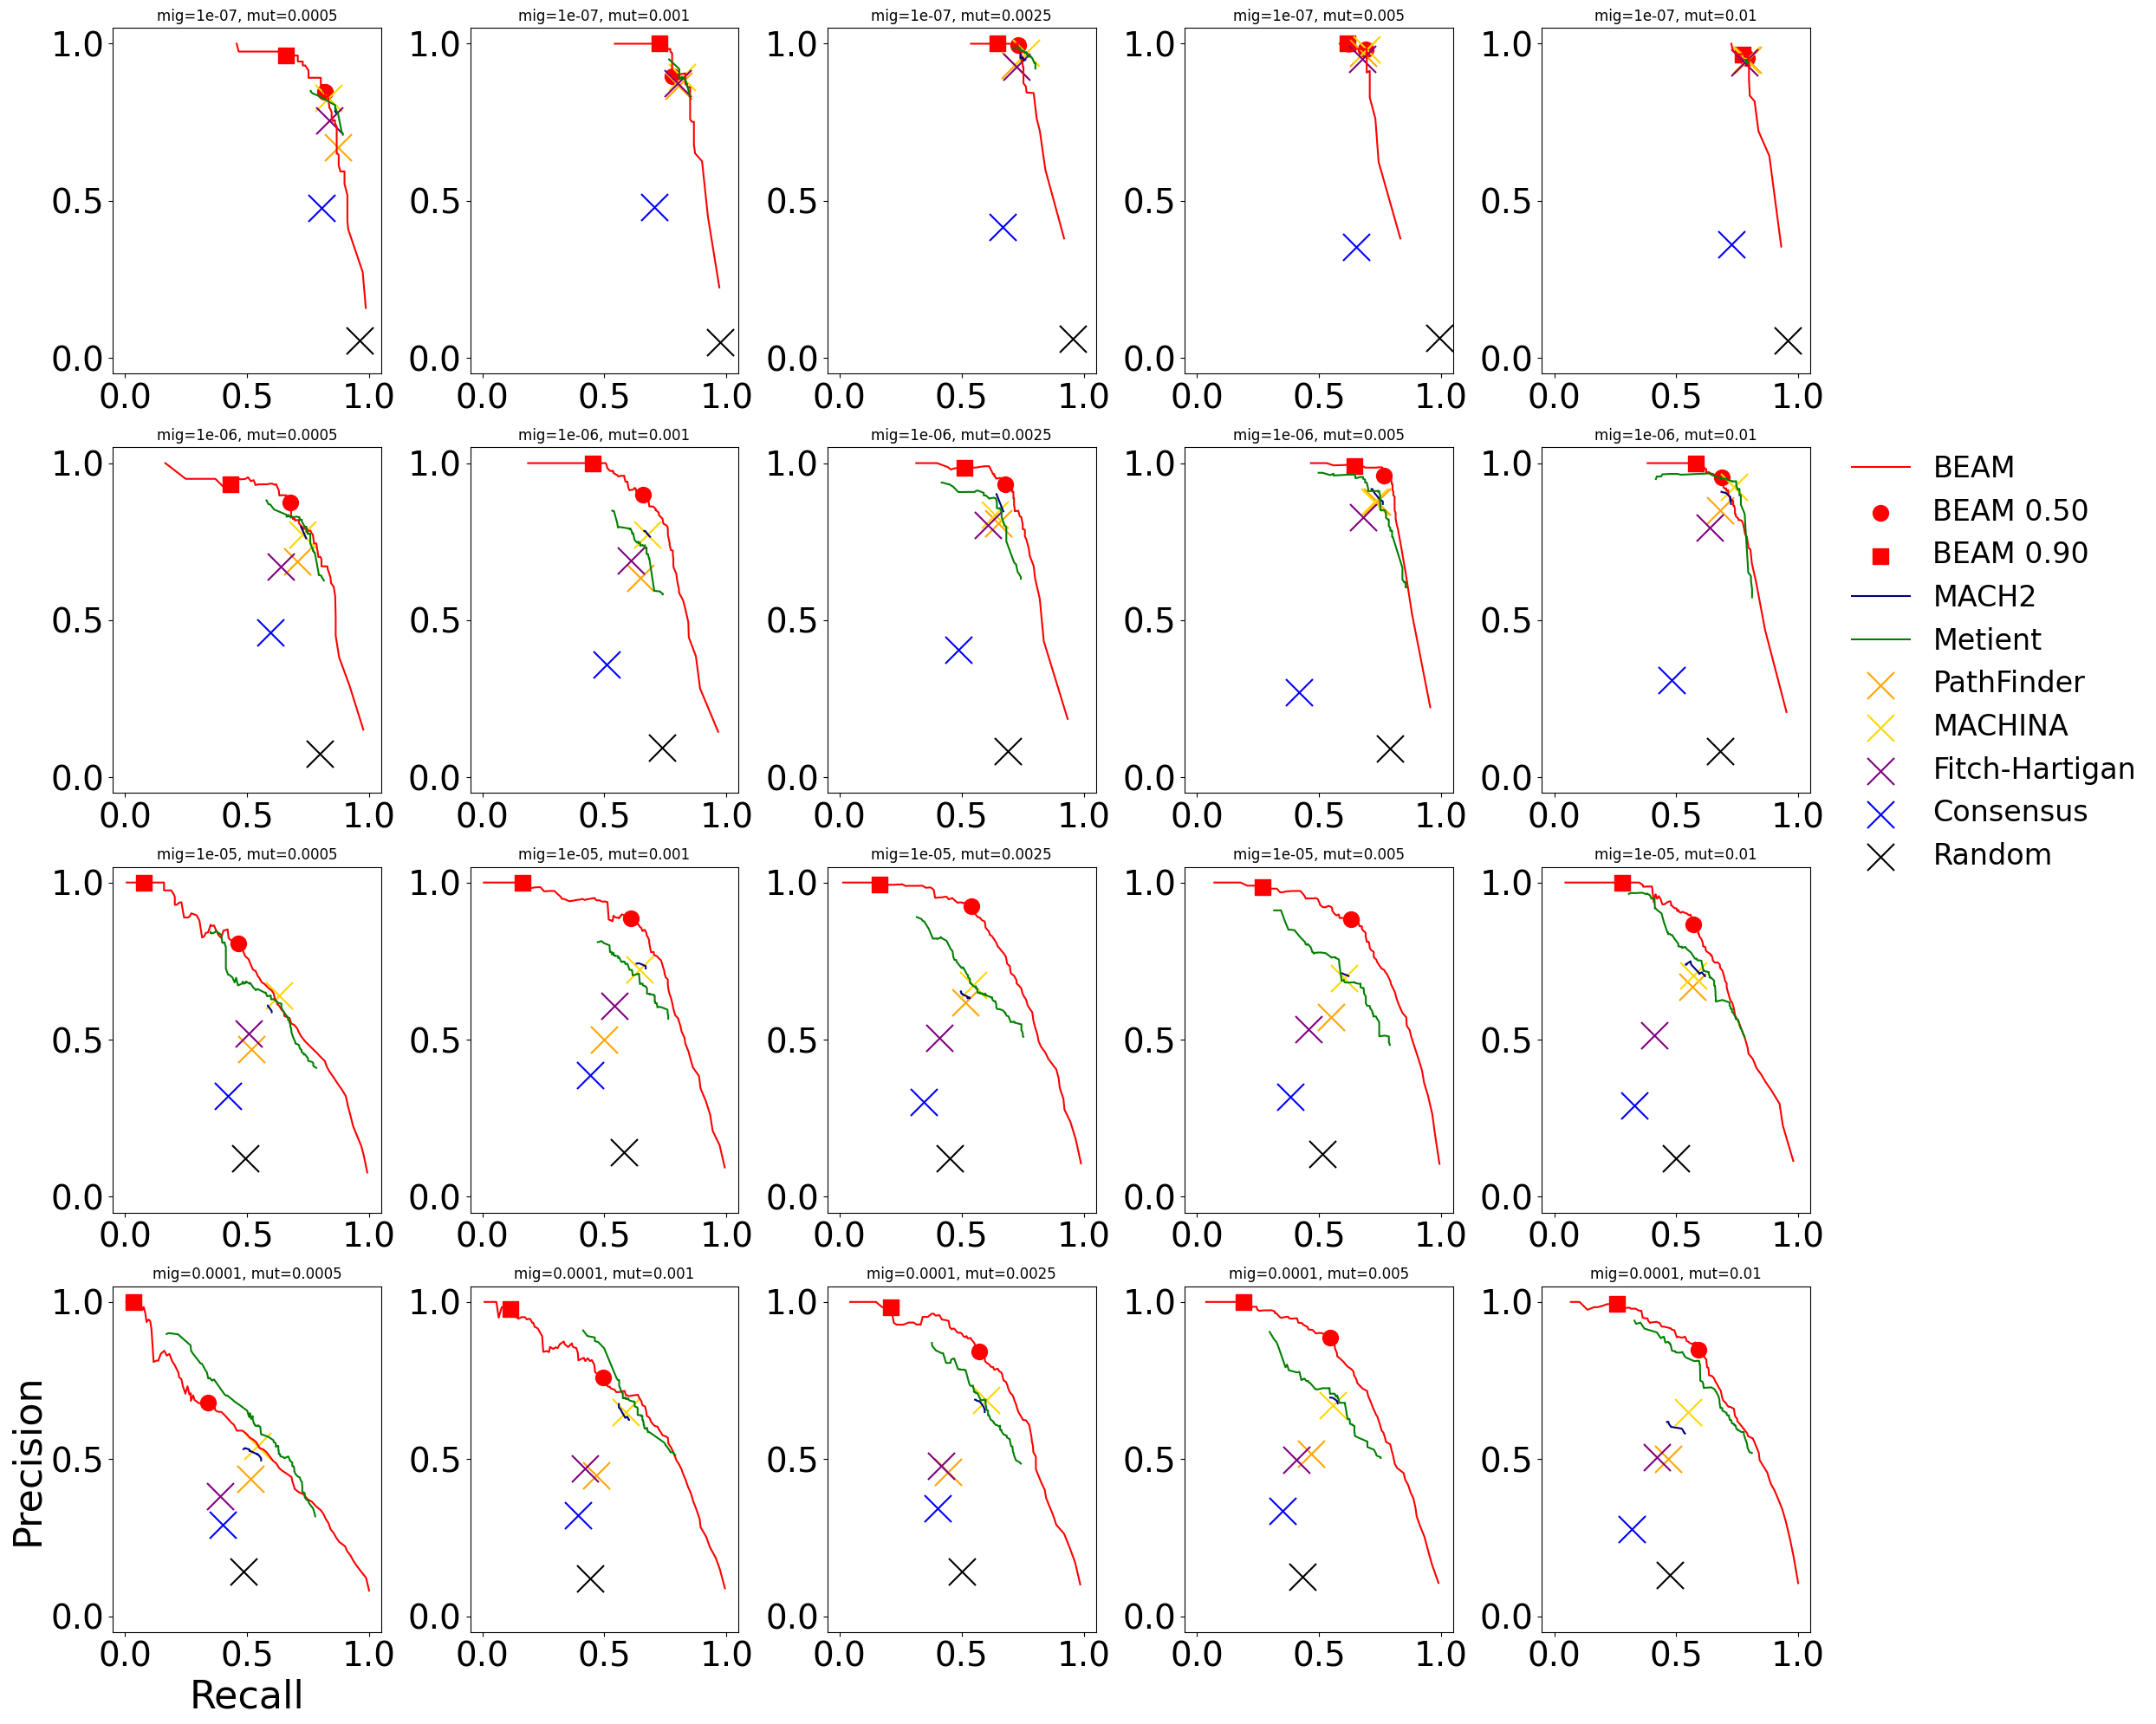

In [12]:
mig_rates = set()
mut_rates = set()
for category, data in precision_recall_data.items():
    mig_rate, mut_rate = parse_var_category(category)
    mig_rates.add(mig_rate)
    mut_rates.add(mut_rate)

mig_rates = sorted(list(mig_rates))
mut_rates = sorted(list(mut_rates))

ncols = len(mut_rates)
nrows = len(mig_rates)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
fs=24
axes = axes.flatten()

i=0
for mig_rate in mig_rates:
    for mut_rate in mut_rates:
        ax = axes[i]
        category_key = reverse_mig_mut_rate_to_category_key(mig_rate, mut_rate)
        data = precision_recall_data[category_key]

        plot_one_pr_panel(
            ax,
            data["pathfinder_precision"], data["pathfinder_recall"],
            data["machina_precision"], data["machina_recall"],
            data["random_precision"], data["random_recall"],
            data["consensus_precision"], data["consensus_recall"],
            data["parsimony_precision"], data["parsimony_recall"],
            data["metient_all_thresh_df"], data["mach2_all_thresh_df"], data["all_thresh_df"]
        )
        ax.set_title(f"mig={mig_rate}, mut={mut_rate}", fontsize=12)
        i+=1

# Turn off all x/y labels except bottom-left
for idx, ax in enumerate(axes):
    row, col = divmod(idx, ncols)
    if not (row == nrows - 1 and col == 0):
        ax.set_xlabel("")
        ax.set_ylabel("")
        

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.0, 0.75), loc="upper right", fontsize=fs, frameon=False)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
# plt.savefig(f"{main_indir}/precision_recall_variable_rates.pdf")
plt.close()
